# 🛰️ Palisades From Space: Burn Scar to Recovery

How did the land inside the Palisades Fire area change from immediately before the January 2025 fire, to the fresh burn scar, to September 2026?

**🌿 Before → 🔥 Fire → 🌱 Recovery**


## 🎯 A little goal for this challenge

The goal of this challenge is to use satellite imagery to understand how the landscape affected by the Palisades Fire changed over time.

The central question is whether changes in vegetation and burned ground can be detected through differences in the wavelengths of light reflected from Earth’s surface.

By comparing Sentinel-2 spectral bands and eventually calculating indices such as the Normalized Burn Ratio (NBR), the challenge aims to turn satellite measurements into a quantitative picture of fire damage and ecological recovery.


---

## 01 · The landscape and the timeline 🌍

The Palisades Fire began January 7, 2025, and was contained on January 31, 2025, after burning 23,448 acres. https://www.fire.ca.gov/incidents/2025/1/7/palisades-fire


### A first look from above 🛰️

I already requested the Sentinel-2 data in the Copernicus Browser so I could have a first look from above. These three screenshots are my visual starting point; now I want to explore the measurements behind them.


### 🌿 Before · January 2, 2025

<div style="width: 360px; max-width: 100%;">

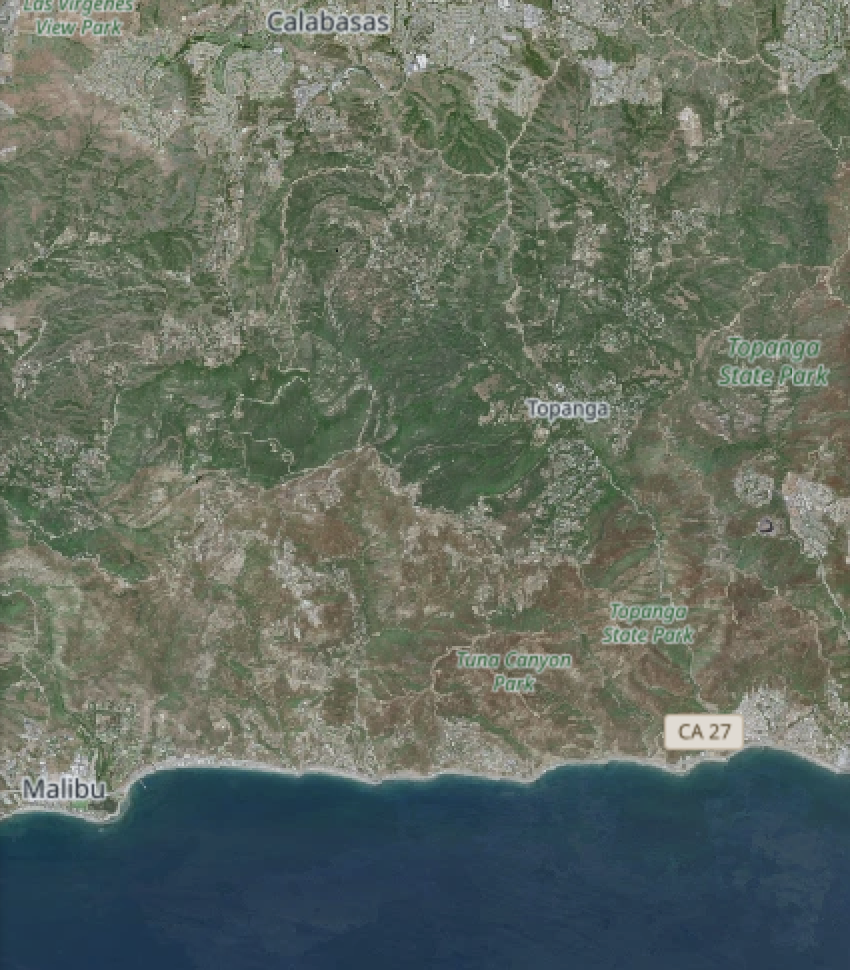

</div>

*Browser overview captured while inspecting the January 2, 2025 catalog result. This is my search context.*


### 🔥 Fresh scar · January 17, 2025

<div style="width: 360px; max-width: 100%;">

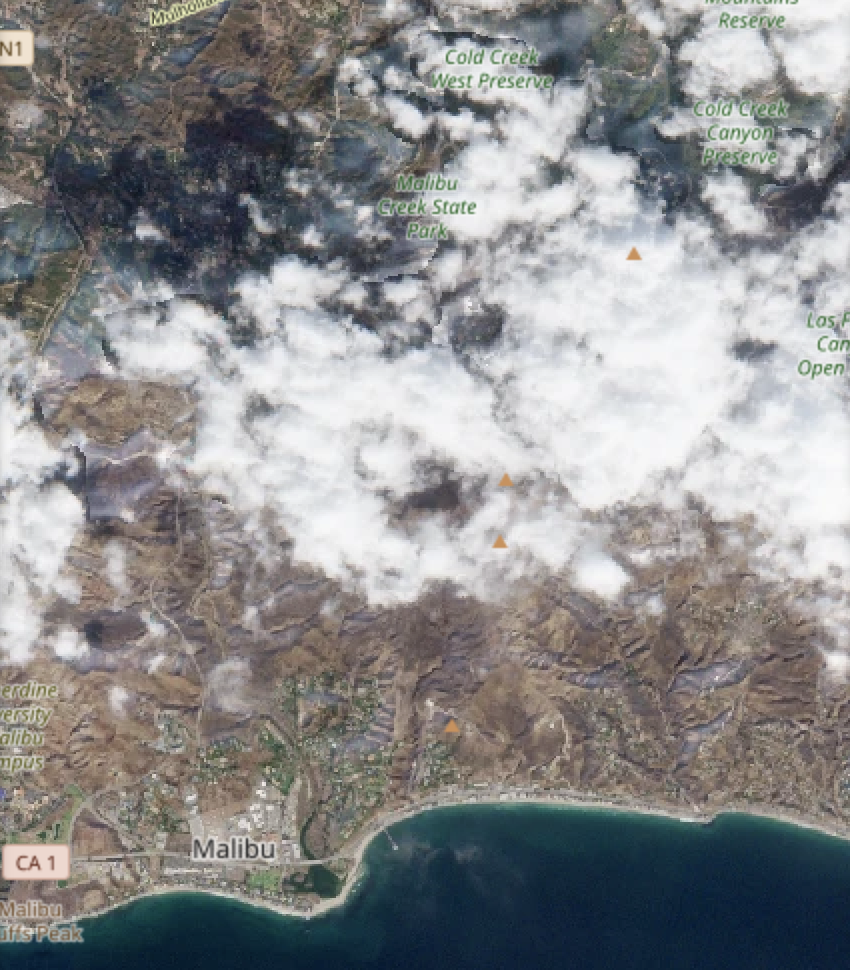

</div>

*My first look in the January window. Clouds cross this preview, which is useful to remember when I choose the pixels to compare.*


### 🌱 Recovery check-in · September 14, 2026

<div style="width: 360px; max-width: 100%;">

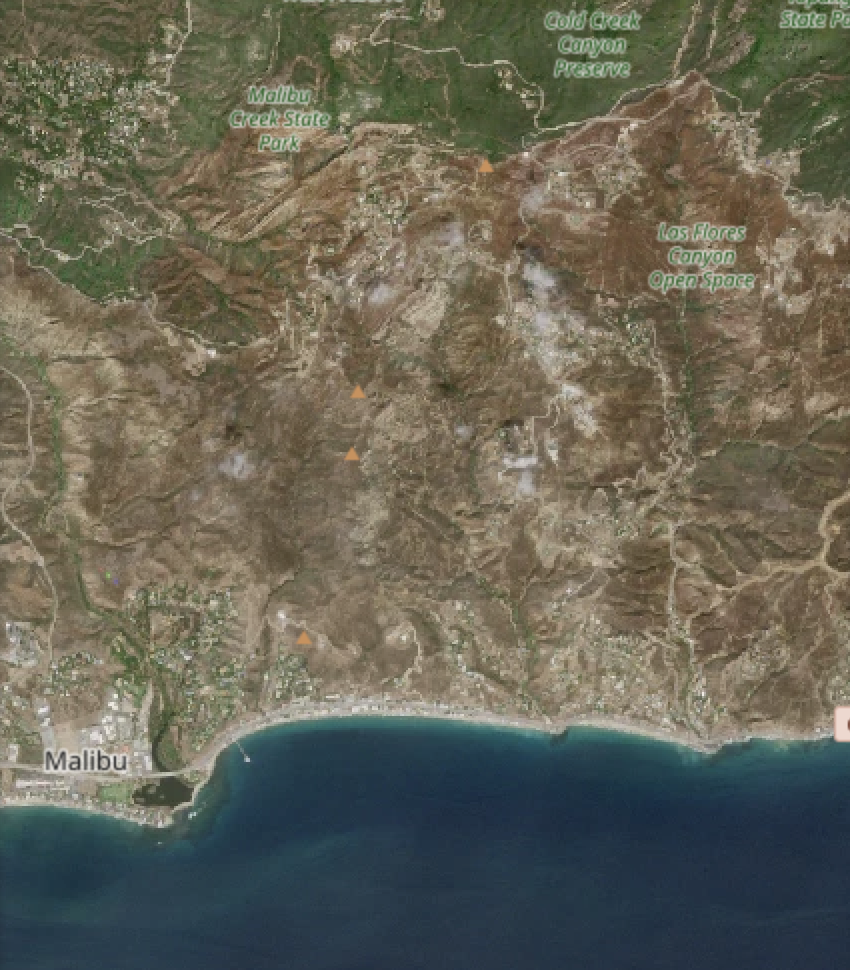

</div>

*My later browser view, ready to investigate alongside the January observations.*

<small>Source: Copernicus Browser · Map attribution: © OpenStreetMap contributors, © Sentinel Hub.</small>


### My three chapters in time

| Stage | Search window | Meaning |
|---|---|---|
| 🌿 **BEFORE** | **Jan 1–6, 2025** | closest clear observation before ignition |
| 🔥 **FRESH SCAR** | **Jan 14–31, 2025** | immediately after containment |
| 🌱 **NOW** | **Sep 1–26, 2026** | current recovery state |


---

## 02 · My little satellite toolkit 🧰

First, the Python tools for finding scenes, opening raster data, and exploring the landscape. Okay, let’s go ✨


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
import rioxarray
import xarray as xr
import geopandas as gpd
import pystac
from pystac_client import Client

### Opening the catalog

The Copernicus catalog is my entry point. I can ask which Sentinel-2 scenes are available for my place and dates.


In [71]:
from pystac_client import Client

catalog = Client.open(
    "https://stac.dataspace.copernicus.eu/v1/"
)

print(catalog.title)

Copernicus Data Space Ecosystem (CDSE) asset-level STAC catalogue


### Framing my patch of Earth 🌍

My bounding box goes **west → south → east → north**. It gives each search the same rectangular area around the Palisades; it is not the fire’s exact boundary.


In [72]:
bbox = [
    -118.6859,   # west longitude
    34.0298,     # south latitude
    -118.5005,   # east longitude
    34.1294      # north latitude
]

---

## 03 · Before the fire 🌿

First, a look at the landscape before ignition. This search gathers the candidate scenes for my January 1–6 window.


In [73]:
# Pre-Fire Scene
search_before = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2025-01-01/2025-01-06",
    query={
        "eo:cloud_cover": {"lte": 30}
    }
)

items_before = list(search_before.items())

print("Number of scenes:", len(items_before))

Number of scenes: 1


### A scene’s little information card ✨

**properties** is a dictionary inside each Item that stores metadata about the observation.

**assets** is another dictionary inside each Item that stores references to the actual data files associated with that observation.


In [74]:
item_before_inspect = items_before[0]  # first scene
print(type(item_before_inspect))  
print(dir(item_before_inspect))  # show available attributes and methods

print("Scene ID:", item_before_inspect.id)
print("Metadata fields:", list(item_before_inspect.properties))
print("Available assets:", list(item_before_inspect.assets))

item_before_inspect.properties  # show metadata names and values

<class 'pystac.item.Item'>
['STAC_OBJECT_TYPE', '__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__geo_interface__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_allow_parent_to_override_href', '_is_protocol', '_is_runtime_protocol', '_object_links', '_repr_html_', '_stac_io', 'add_asset', 'add_derived_from', 'add_link', 'add_links', 'assets', 'bbox', 'clear_links', 'clone', 'collection_id', 'common_metadata', 'datetime', 'delete_asset', 'ext', 'extra_fields', 'from_dict', 'from_file', 'full_copy', 'geometry', 'get_assets', 'get_collection', 'get_datetime', 'get_derived_from', 'get_links', 'get_parent

{'gsd': 10,
 'created': '2025-01-02T23:09:30.000000Z',
 'updated': '2025-01-02T23:18:19.333643Z',
 'datetime': '2025-01-02T18:37:51.024Z',
 'platform': 'sentinel-2a',
 'grid:code': 'MGRS-11SLT',
 'published': '2025-01-02T23:17:16.340875Z',
 'statistics': {'water': 54.858392,
  'nodata': 7e-06,
  'dark_area': 2.107412,
  'vegetation': 7.284164,
  'thin_cirrus': 0.001888,
  'cloud_shadow': 0.000415,
  'unclassified': 0.002445,
  'not_vegetated': 32.728201,
  'high_proba_clouds': 0.819748,
  'medium_proba_clouds': 2.194127,
  'saturated_defective': 0.0},
 'instruments': ['msi'],
 'auth:schemes': {'s3': {'type': 's3'},
  'oidc': {'type': 'openIdConnect',
   'openIdConnectUrl': 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/.well-known/openid-configuration'}},
 'end_datetime': '2025-01-02T18:37:51.024Z',
 'product:type': 'S2MSI2A',
 'view:azimuth': 102.06297670778824,
 'constellation': 'sentinel-2',
 'eo:snow_cover': 0.0,
 'eo:cloud_cover': 3.02,
 'start_datetime': '2025-01-02T1

---

## 04 · Looking for the fresh scar 🔥

Now I ask for scenes in my January 14–31 window. This gives me the next set of observations to inspect alongside the before scenes.


In [75]:
# Post-Fire Scene
search_after = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2025-01-14/2025-01-31",
    query={
        "eo:cloud_cover": {"lte": 30}
    }
)

items_after = list(search_after.items())

print("Number of scenes:", len(items_after))

Number of scenes: 1


---

## 05 · Checking back in 🌱

Hello again, Palisades. My September 2026 search gathers the later observations so I can investigate what changed during the recovery period.


In [76]:
# Recovery Scene
search_recovery = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2026-09-01/2026-09-25",
    query={
        "eo:cloud_cover": {"lte": 30}
    }
)

items_recovery = list(search_recovery.items())

print("Number of scenes:", len(items_recovery))

Number of scenes: 4


### My little scene shortlist ✨

Three lists, three chapters of the same landscape. These counts tell me how many candidate scenes I found; choosing the observations to compare comes next.


In [77]:
print("Before:", len(items_before))
print("After:", len(items_after))
print("Recovery:", len(items_recovery))

Before: 1
After: 1
Recovery: 4


---

## 06 · First, the formula 🛰️

My index is the **Normalized Burn Ratio (NBR)**:

$$\mathrm{NBR} = \frac{\mathrm{NIR} - \mathrm{SWIR}}{\mathrm{NIR} + \mathrm{SWIR}}$$

Subtract first, add first, then divide. The parentheses matter! Here, **SWIR means the longer-wave SWIR band, B12**. This calculation happens separately for every pixel.

Formula checked against [USGS](https://www.usgs.gov/landsat-missions/landsat-normalized-burn-ratio).

In [78]:
def calculate_nbr(nir, swir):
    return (nir - swir) / (nir + swir)

### Which satellite fields go into that formula?

I use **B8A** for near-infrared and **B12** for shortwave-infrared. Both have **20 m pixels**, which keeps the comparison simple. The scene-classification layer helps me remove clouds, shadows, and water.

| What I need | Sentinel-2 band | Copernicus asset | Earth Search asset |
|---|---|---|---|
| NIR | B8A · narrow near-infrared | `B8A_20m` | `nir08` |
| SWIR | B12 · shortwave-infrared | `B12_20m` | `swir22` |
| Pixel classification | SCL | `SCL_20m` | `scl` |

Band resolutions: [Copernicus Sentinel-2 products](https://sentiwiki.copernicus.eu/web/s2-products).

In [79]:
nir_band = "nir08"      # B8A: near-infrared
swir_band = "swir22"    # B12: shortwave-infrared
scl_band = "scl"        # Scene classification

## 07 · Find the files for my three dates 📅

My Copernicus searches above found the scene metadata. To read the actual pixels, I use public Sentinel-2 Level-2A copies in **Earth Search, Collection 1**. The asset names differ, as the table shows.

I keep my three browser dates and use **tile 11SLT** every time. The small function below finds one scene for a date; it stops if that scene is missing or ambiguous, so it cannot silently choose another date.

Public raster access and scaling: [Earth Search documentation](https://github.com/Element84/earth-search).

In [80]:
before_date = "2025-01-02"
after_date = "2025-01-17"
recovery_date = "2026-09-14"

image_catalog = Client.open("https://earth-search.aws.element84.com/v1")

def find_scene(date):
    search = image_catalog.search(
        collections=["sentinel-2-c1-l2a"],
        bbox=bbox,
        datetime=date,
        query={"grid:code": {"eq": "MGRS-11SLT"}},
        method="GET",
    )
    scenes = list(search.items())
    if len(scenes) != 1:
        raise ValueError(f"Expected one scene for {date}; found {len(scenes)}.")
    return scenes[0]

In [81]:
scene_before = find_scene(before_date)
scene_after = find_scene(after_date)
scene_recovery = find_scene(recovery_date)

print(f"1 — Before: {scene_before.datetime.date()} | {scene_before.id}")
print(f"2 — Fresh scar: {scene_after.datetime.date()} | {scene_after.id}")
print(f"3 — Recovery: {scene_recovery.datetime.date()} | {scene_recovery.id}")

/opt/anaconda3/envs/test/lib/python3.11/site-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


1 — Before: 2025-01-02 | S2A_T11SLT_20250102T183754_L2A
2 — Fresh scar: 2025-01-17 | S2B_T11SLT_20250117T183840_L2A
3 — Recovery: 2026-09-14 | S2C_T11SLT_20260914T183526_L2A


### Here is how a band becomes a file link

An item holds its assets. The asset's `href` is the file address. Here are the two files for the first date:

In [82]:
nir_before_url = scene_before.assets[nir_band].href
swir_before_url = scene_before.assets[swir_band].href

print(f"NIR file: {nir_before_url}")
print(f"SWIR file: {swir_before_url}")

NIR file: https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/11/S/LT/2025/1/S2A_T11SLT_20250102T183754_L2A/B8A.tif
SWIR file: https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/11/S/LT/2025/1/S2A_T11SLT_20250102T183754_L2A/B12.tif


## 08 · Open a band and keep my study area 🌍

This little reader does three things: **open the file → crop to my bounding box → load the pixels**. Missing pixels become `NaN`.

The spectral files store whole-number measurements. Their metadata supplies the conversion to reflectance: **stored value × scale + offset**. I apply that once; the SCL class numbers stay as they are. For these scenes, the spectral scale is `0.0001` and the offset is `-0.1`.

In [83]:
def read_band(scene, band_name):
    asset = scene.assets[band_name]

    with rio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"):
        with rioxarray.open_rasterio(asset.href, masked=True) as raster:
            band = raster.squeeze("band", drop=True)
            band = band.rio.clip_box(*bbox, crs="EPSG:4326").load()

    if band_name != scl_band:
        band_info = asset.extra_fields["raster:bands"][0]
        band = band * band_info["scale"] + band_info["offset"]

    return band

### 1 · Read the before bands

In [84]:
nir_before = read_band(scene_before, nir_band)
swir_before = read_band(scene_before, swir_band)
scl_before = read_band(scene_before, scl_band)

print(f"Before: {nir_before.shape[0]} rows × {nir_before.shape[1]} columns")

Before: 567 rows × 865 columns


### 2 · Read the fresh-scar bands

In [85]:
nir_after = read_band(scene_after, nir_band)
swir_after = read_band(scene_after, swir_band)
scl_after = read_band(scene_after, scl_band)

print(f"Fresh scar: {nir_after.shape[0]} rows × {nir_after.shape[1]} columns")

Fresh scar: 567 rows × 865 columns


### 3 · Read the recovery bands

In [86]:
nir_recovery = read_band(scene_recovery, nir_band)
swir_recovery = read_band(scene_recovery, swir_band)
scl_recovery = read_band(scene_recovery, scl_band)

print(f"Recovery: {nir_recovery.shape[0]} rows × {nir_recovery.shape[1]} columns")

Recovery: 567 rows × 865 columns


### Same pixels, same places

These files use the same tile and 20 m grid. I check the coordinate system and pixel coordinates before subtracting anything. A mismatch should make this cell stop.

In [87]:
for band in [swir_before, scl_before, nir_after, swir_after, scl_after,
             nir_recovery, swir_recovery, scl_recovery]:
    assert band.rio.crs == nir_before.rio.crs, "The coordinate systems differ."
    xr.align(nir_before, band, join="exact")

print("All bands use the same pixel grid.")

All bands use the same pixel grid.


## 09 · Keep clear land in all three images ☁️

SCL class **4 = vegetation** and **5 = non-vegetated land**. Keeping these two classes excludes water, cloud, cloud shadow, snow, and uncertain pixels. The catalog's cloud percentage alone cannot do this for individual pixels. [Copernicus SCL definitions](https://sentiwiki.copernicus.eu/web/s2-processing).

In [88]:
clear_before = scl_before.isin([4, 5])
clear_after = scl_after.isin([4, 5])
clear_recovery = scl_recovery.isin([4, 5])

I also exclude negative or missing reflectance and a zero denominator. Then I keep only pixels usable on **all three dates**, so the three means describe the same ground.

In [89]:
valid_before = (nir_before >= 0) & (swir_before >= 0) & (nir_before + swir_before > 0)
valid_after = (nir_after >= 0) & (swir_after >= 0) & (nir_after + swir_after > 0)
valid_recovery = (nir_recovery >= 0) & (swir_recovery >= 0) & (nir_recovery + swir_recovery > 0)

shared_pixels = (clear_before & clear_after & clear_recovery
                 & valid_before & valid_after & valid_recovery)

pixel_count = int(shared_pixels.sum())
if pixel_count == 0:
    raise ValueError("No clear land pixels are shared by all three dates.")

print(f"I can compare {pixel_count:,} shared clear land pixels.")
print(f"That is {pixel_count / shared_pixels.size:.1%} of the cropped grid.")

I can compare 91,659 shared clear land pixels.
That is 18.7% of the cropped grid.


In [90]:
nir_before = nir_before.where(shared_pixels)
swir_before = swir_before.where(shared_pixels)

nir_after = nir_after.where(shared_pixels)
swir_after = swir_after.where(shared_pixels)

nir_recovery = nir_recovery.where(shared_pixels)
swir_recovery = swir_recovery.where(shared_pixels)

## 10 · Now use the formula ✨

Same formula, three dates. Each result is a little map of NBR values.

In [91]:
nbr_before = calculate_nbr(nir_before, swir_before)
nbr_after = calculate_nbr(nir_after, swir_after)
nbr_recovery = calculate_nbr(nir_recovery, swir_recovery)

### Look at the three periods together

All three views use the same color scale and the same clear-land mask. Blank pixels were excluded. Higher NBR means more NIR relative to SWIR; it is not a percentage of vegetation.

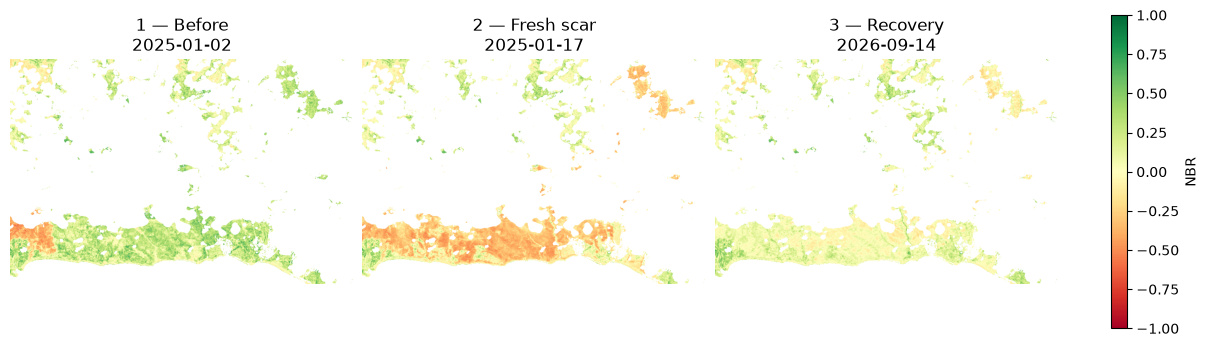

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")

image = axes[0].imshow(nbr_before, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title(f"1 — Before\n{before_date}")

axes[1].imshow(nbr_after, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title(f"2 — Fresh scar\n{after_date}")

axes[2].imshow(nbr_recovery, cmap="RdYlGn", vmin=-1, vmax=1)
axes[2].set_title(f"3 — Recovery\n{recovery_date}")

for ax in axes:
    ax.set_axis_off()

fig.colorbar(image, ax=axes, label="NBR", shrink=0.8)
plt.show()

## 11 · What changed? 🌿 → 🔥 → 🌱

First, the mean NBR of the same clear land pixels in each period:

In [93]:
mean_before = float(nbr_before.mean())
mean_after = float(nbr_after.mean())
mean_recovery = float(nbr_recovery.mean())

print(f"1 — Before: mean NBR = {mean_before:.3f}")
print(f"2 — Fresh scar: mean NBR = {mean_after:.3f}")
print(f"3 — Recovery: mean NBR = {mean_recovery:.3f}")

1 — Before: mean NBR = 0.187
2 — Fresh scar: mean NBR = -0.121
3 — Recovery: mean NBR = 0.075


Now subtract **later − earlier**. Positive means NBR increased; negative means it decreased. These are changes in index units, not percentages.

In [94]:
change_1_to_2 = nbr_after - nbr_before
change_2_to_3 = nbr_recovery - nbr_after
change_1_to_3 = nbr_recovery - nbr_before

print(f"1 → 2 | Before to fresh scar: mean NBR changed by {float(change_1_to_2.mean()):+.3f}.")
print(f"2 → 3 | Fresh scar to recovery: mean NBR changed by {float(change_2_to_3.mean()):+.3f}.")
print(f"1 → 3 | Before to recovery: mean NBR changed by {float(change_1_to_3.mean()):+.3f}.")

1 → 2 | Before to fresh scar: mean NBR changed by -0.308.
2 → 3 | Fresh scar to recovery: mean NBR changed by +0.197.
1 → 3 | Before to recovery: mean NBR changed by -0.111.


## 12 · My takeaway 🌿 → 🔥 → 🌱

Looking at these three images, it feels like the satellites caught an echo of the horrific story unfolding on the ground. Across the same **91,659 clear land pixels in my study box (18.7% of the cropped grid ,** mean NBR was **0.187 on January 2, 2025**). Higher NBR means more near-infrared reflected relative to shortwave-infrared, which fits the greener colors in the first image. By **January 17, 2025**, mean NBR had fallen to **−0.121**, a change of **−0.308**. That shift toward the lower, warmer part of the color scale is consistent with the fire’s impact: vegetation loss and changes in moisture and burned surfaces change the balance of reflected NIR and SWIR. By **September 14, 2026**, mean NBR had risen to **0.075**, an increase of **+0.197** from January 17, while still sitting **0.111 below the before-fire value**, an overall change of **−0.111**. So I can see a sharp drop followed by a **partial rebound in the satellite signal**, with NBR still below its starting point. Seasonal differences and the land included in our box, including land outside the fire perimeter, mean this alone cannot tell me how fully the ecosystem has recovered. Even with that distinction, seeing this pattern emerge from real measurements of reflected light is such a powerful finding. ✨